In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob
from math import log2

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution

### Load Recast Data

In [2]:
# inputFiles = ['../CMS-EXO-20-004/scanResults_scalar_cms_nocut.pcl', 
#               '../CMS-EXO-20-004/scanResults_pseudoscalar_cms_nocut.pcl']

inputFiles = ['../CMS-EXO-20-004/scanResults_scalar_pt_nocut.pcl',
              '../CMS-EXO-20-004/scanResults_pseudoscalar_pt_nocut.pcl']


# inputFiles = ['/home/camila/Workstation-backup/pcl-files/scanResults_scalar_cms_nocut.pcl',
#               '/home/camila/Workstation-backup/pcl-files/scanResults_pseudoscalar_cms_nocut.pcl']

# inputFiles = ['../CMS-EXO-20-004/AuxInfo/CMS-EXO-20-004-data/DMsimp_spin-1_Monojet_DF.pcl']



dfs = [pd.read_pickle(i) for i in inputFiles]
recastData = pd.concat(dfs, ignore_index=True)

In [3]:
recastData

,Coupling,Mode,$m_{med}$,$m_{DM}$,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,...,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$),$\mu^{UL}_{obs}$,$\mu^{UL}_{exp}$
0,Scalar,DM+QCDjets,10.0,150.0,2018,59.7,7.838363,1.054103,1.054103,5.546094,...,0.057246,0.049818,0.049509,0.049010,0.047521,0.047521,0.045142,0.038842,173.732249,124.785377
1,Scalar,DM+QCDjets,10.0,150.0,2017,41.5,5.364219,0.424543,0.424543,4.821725,...,0.056206,0.048579,0.048347,0.047876,0.044533,0.044533,0.044533,0.044533,173.732249,124.785377
2,Scalar,DM+QCDjets,10.0,150.0,2016,36.0,4.907088,0.242388,0.242388,4.472132,...,0.054954,0.046725,0.046546,0.046037,0.044225,0.044225,0.044225,0.044225,173.732249,124.785377
3,Scalar,DM+QCDjets,10.0,500.0,2018,59.7,0.025062,0.002535,0.002535,0.022341,...,0.189410,0.162185,0.161355,0.160338,0.155955,0.155955,0.148450,0.129804,9599.793701,5808.251342
4,Scalar,DM+QCDjets,10.0,500.0,2017,41.5,0.019437,0.001839,0.001839,0.016653,...,0.179888,0.152216,0.151649,0.150830,0.148116,0.148116,0.148116,0.148116,9599.793701,5808.251342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,Pseudoscalar,DM+QCDjets,3000.0,1200.0,2017,41.5,0.003583,0.000145,0.000145,0.003135,...,0.268716,0.229718,0.227259,0.225643,0.221620,0.221620,0.221620,0.221620,28844.241821,13689.865971
503,Pseudoscalar,DM+QCDjets,3000.0,1200.0,2016,36.0,0.003140,0.000140,0.000140,0.002838,...,0.268847,0.231767,0.230166,0.228557,0.224863,0.224863,0.224863,0.224863,28844.241821,13689.865971
504,Pseudoscalar,DM+QCDjets,3000.0,1400.0,2018,59.7,0.002315,0.000087,0.000087,0.001907,...,0.276314,0.237907,0.235879,0.234319,0.229862,0.229862,0.218729,0.193569,49797.791012,24632.257972
505,Pseudoscalar,DM+QCDjets,3000.0,1400.0,2017,41.5,0.002015,0.000082,0.000082,0.001600,...,0.269984,0.232619,0.230401,0.228560,0.223737,0.223737,0.223737,0.223737,49797.791012,24632.257972


In [4]:
recastData[recastData['$m_{DM}$']==150]

,Coupling,Mode,$m_{med}$,$m_{DM}$,Data-takingperiod,Luminosity (1/fb),bin_250.0_280.0,bin_250.0_280.0_ErrorPlus,bin_250.0_280.0_ErrorMinus,bin_280.0_310.0,...,Tauveto,Bjetveto,Photonveto,"$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad",LeadingAK4jet$p_{T}>100$GeV,LeadingAK4jet$\eta<2.4$,HCALmitigation(jets),HCALmitigation($\phi^{miss}$),$\mu^{UL}_{obs}$,$\mu^{UL}_{exp}$
0,Scalar,DM+QCDjets,10.0,150.0,2018,59.7,7.838363,1.054103,1.054103,5.546094,...,0.057246,0.049818,0.049509,0.049010,0.047521,0.047521,0.045142,0.038842,173.732249,124.785377
1,Scalar,DM+QCDjets,10.0,150.0,2017,41.5,5.364219,0.424543,0.424543,4.821725,...,0.056206,0.048579,0.048347,0.047876,0.044533,0.044533,0.044533,0.044533,173.732249,124.785377
2,Scalar,DM+QCDjets,10.0,150.0,2016,36.0,4.907088,0.242388,0.242388,4.472132,...,0.054954,0.046725,0.046546,0.046037,0.044225,0.044225,0.044225,0.044225,173.732249,124.785377
27,Scalar,DM+QCDjets,250.0,150.0,2018,59.7,13.106898,0.754618,0.754618,9.454077,...,0.048151,0.041842,0.041612,0.041205,0.039414,0.039414,0.036312,0.031061,79.136066,57.744500
28,Scalar,DM+QCDjets,250.0,150.0,2017,41.5,11.871772,0.670697,0.670697,8.866545,...,0.045532,0.039509,0.039318,0.038891,0.037582,0.037582,0.037582,0.037582,79.136066,57.744500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,Pseudoscalar,DM+QCDjets,2750.0,150.0,2017,41.5,0.058622,0.002854,0.002854,0.054084,...,0.106576,0.092443,0.091690,0.090651,0.087979,0.087979,0.087979,0.087979,6355.473231,2908.405891
476,Pseudoscalar,DM+QCDjets,2750.0,150.0,2016,36.0,0.057809,0.002879,0.002879,0.040912,...,0.108003,0.092916,0.092484,0.091725,0.088127,0.088127,0.088127,0.088127,6355.473231,2908.405891
492,Pseudoscalar,DM+QCDjets,3000.0,150.0,2018,59.7,0.056065,0.002365,0.002365,0.037514,...,0.107083,0.093340,0.092943,0.091872,0.088962,0.088962,0.085121,0.073440,11038.075361,5109.796080
493,Pseudoscalar,DM+QCDjets,3000.0,150.0,2017,41.5,0.041615,0.002033,0.002033,0.036119,...,0.105929,0.093104,0.092648,0.091627,0.088921,0.088921,0.088921,0.088921,11038.075361,5109.796080


### Get all model points

In [5]:
models = []
mCols = ['Coupling', 'Mode', '$m_{med}$', '$m_{DM}$', '$g_{DM}$', '$g_{q}$']
for row in recastData[mCols].values:
    m = dict(zip(mCols, row.tolist()))
    if m not in models:
        models.append(m)

print('%i models loaded.' %len(models))

169 models loaded.


### Get models parameters

In [6]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'Coupling': ['Pseudoscalar', 'Scalar'], 'Mode': 'DM+QCDjets', '$m_{med}$': [1250.0, 995.0, 100.0, 2500.0, 295.0, 200.0, 1000.0, 10.0, 1995.0, 2250.0, 750.0, 2000.0, 500.0, 1750.0, 3000.0, 250.0, 1500.0, 2750.0], '$m_{DM}$': [1.0, 1000.0, 10.0, 1200.0, 500.0, 150.0, 1400.0], '$g_{DM}$': 1.0, '$g_{q}$': 1.0}
Coupling = ['Pseudoscalar', 'Scalar']
Mode = DM+QCDjets
$g_{DM}$ = 1.0
$g_{q}$ = 1.0


### Filter parameters

In [12]:
paramFilter = {
    'Mode' : 'DM+QCDjets',
    '$m_{med}$' : 3000.,
    '$m_{DM}$' : 150.,
    '$g_{DM}$' : 1.,
#     '$g_{q}$' : .25,
    'Data-takingperiod' : 2016
}

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in paramFilter.items()])
dfModel = recastData.loc[(recastData[list(paramFilter)] == pd.Series(paramFilter)).all(axis=1)]

In [13]:
dfModel.T

,257,494
Coupling,Scalar,Pseudoscalar
Mode,DM+QCDjets,DM+QCDjets
$m_{med}$,3000.0,3000.0
$m_{DM}$,150.0,150.0
Data-takingperiod,2016,2016
...,...,...
LeadingAK4jet$\eta<2.4$,0.11071,0.088126
HCALmitigation(jets),0.11071,0.088126
HCALmitigation($\phi^{miss}$),0.11071,0.088126
$\mu^{UL}_{obs}$,14354.265719,11038.075361


In [14]:
eff = np.array([0.0391, 0.0238, 0.0238, 0.00452, 0.00411, 0.00429, 0.00269, 0.000591])

The efficiency for the $i$-th bin, $\epsilon_{i}$, is given by:

$$ \epsilon_{i} = \frac{n^{i}_{s}}{\sigma_{T}\mathcal{L}},   $$
where $n^{i}_{s}$ is the number of events in the correspondent bin, $\sigma_{T}$ is the total cross-section, and $\mathcal{L}$ is the integrated luminosity.  

### Auxiliar functions for plotting

In [15]:
def getBins(dfModel,rightBin = 1400.):
    
    bins = {c : eval(c.split('_')[1]) for c in dfModel.columns if ("bin_" in c and not 'Error' in c)}
    binsError = {c : eval(c.split('_')[1]) for c in dfModel.columns if ("bin_" in c and 'ErrorPlus' in c)}    
    binCenter = (np.array(list(bins.values()))+np.diff(list(bins.values())+[rightBin])/2).tolist()    
    binLeft = [bins[c] for c in bins]+[rightBin] 
    
    return bins,binsError,binCenter,binLeft


def getEfficiencies(dfSingle, bins, binsError):
    
    xsec = dfSingle['Total xsec (pb)'].iloc[0]
    lumi = dfSingle['Luminosity (1/fb)'].iloc[0]
    eff = {}
    ns = {c: dfSingle[c].iloc[0] for c in bins}
    nsErr = {c : dfSingle[c].iloc[0] for c in binsError}
    effErr = {}
    for c in bins:
        if ns[c] == 0:
            eff[c] = 0
            effErr[f'{c}_Error'] = 0
        else:
            eff[c] = dfSingle[c].iloc[0]/(xsec*1e3*lumi)
            effErr[f'{c}_Error'] = nsErr[f'{c}_ErrorPlus']*eff[c]/ns[c]
    
    return eff, effErr

### Plot Efficiencies

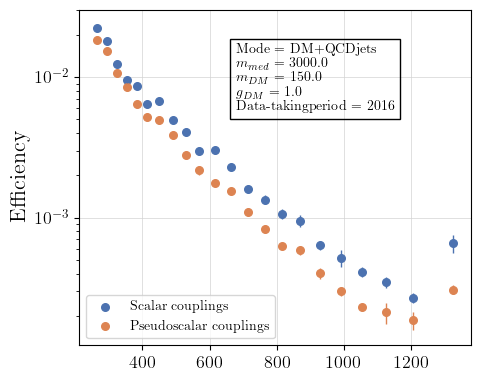

In [19]:
bins, binsError, binCenter, binLeft = getBins(dfModel)

fig, ax = plt.subplots()

data = pd.DataFrame(columns=['Scalar','Pseudoscalar'])
dataError = pd.DataFrame(columns=['Scalar','Pseudoscalar'])


colors = {label : sns.color_palette('deep')[i] for i,label in enumerate(data.keys())}    

for label in dfModel['Coupling']:
    dfSingle = dfModel[dfModel['Coupling'] == label]
    data[label], dataError[label] = getEfficiencies(dfSingle, bins, binsError)
 
    eff = np.array([data[label][c] for c in bins])
    effErr = np.array([dataError[label][f'{c}_Error'] for c in bins])
    
    ax.scatter(x=binCenter, y=eff, s=30, color=colors[label], label=r'%s couplings' %(label))
    ax.errorbar(binCenter, eff, yerr=effErr, marker='.', 
                   elinewidth=1.0, drawstyle='steps-mid',linewidth=0.0, color=colors[label])

    
ax.set_yscale('log')
ax.text(.4, .7, textstr, fontsize=10, bbox=dict(facecolor='none', edgecolor='black'), 
           transform=plt.gca().transAxes)



ax.set_ylabel('Efficiency')
ax.legend()
# plt.grid()
plt.tight_layout()
plt.savefig('efficiencies_spin0_3000_150.png')

plt.show()

In [10]:
data

,Vector
bin_250.0_280.0,0.012691
bin_280.0_310.0,0.010351
bin_310.0_340.0,0.007646
bin_340.0_370.0,0.006430
bin_370.0_400.0,0.005212
bin_400.0_430.0,0.004215
bin_430.0_470.0,0.004834
bin_470.0_510.0,0.004030
bin_510.0_550.0,0.002877
bin_550.0_590.0,0.002528


In [11]:
data.iloc[17]*(36/137)

Vector    0.000105
Name: bin_960.0_1020.0, dtype: float64

In [11]:
0.0004019312906*(36/137)

0.00010561698147153286

In [ ]:
bin_960.0_1020.0

In [34]:
cutVals = np.array(cutflow.iloc[0])

In [40]:
for i, e in enumerate(reversed(float(data.iloc[17])*cutVals[::-1]/cutVals)):
    print(cutflow.columns[i],'  ', e)

Fullsample    0.0011120173489853082
Triggeremulation    0.00110258954262247
$p_{T}^{miss}>250$GeV    0.00048161696776850566
Electronveto    0.0004809428782429312
Tauveto    0.0004628905229380523
Bjetveto    0.00041084608024219107
Photonveto    0.0003932099394261565
$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad    0.00034899993480126944
LeadingAK4jet$p_{T}>100$GeV    0.00033590010297211465
LeadingAK4jet$\eta<2.4$    0.0003354299643428591
HCALmitigation(jets)    0.00014651758980161177
HCALmitigation($\phi^{miss}$)    0.0001452753974323472


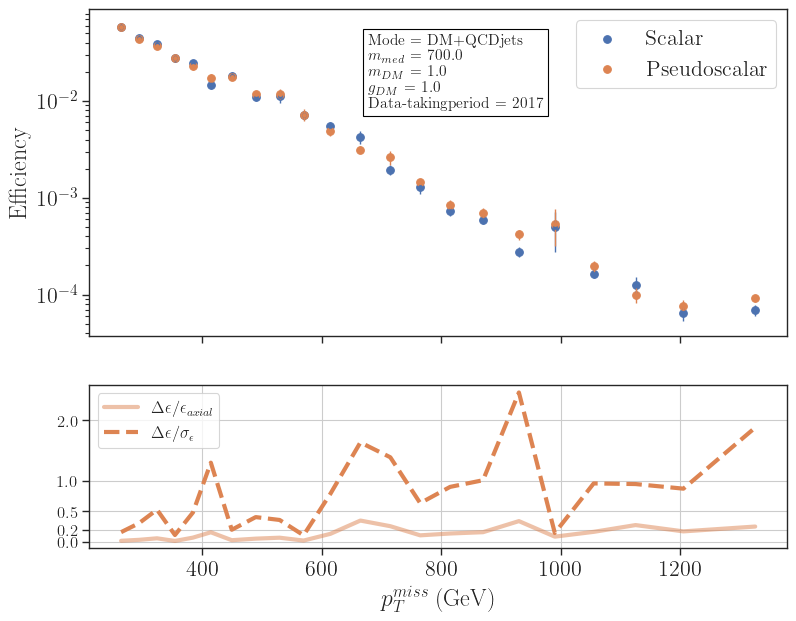

In [10]:
bins, binsError, binCenter, binLeft = getBins(dfModel)

fig, ax = plt.subplots(2,sharex=True, gridspec_kw = {'height_ratios':[2, 1]},figsize=(9,7))

# data = pd.DataFrame(columns=['Axial', 'Vector'])
# dataError = pd.DataFrame(columns=['Axial', 'Vector'])

data = pd.DataFrame(columns=['Scalar', 'Pseudoscalar'])
dataError = pd.DataFrame(columns=['Scalar', 'Pseudoscalar'])

colors = {label : sns.color_palette('deep')[i] for i,label in enumerate(data.keys())}    

for label in dfModel['Coupling']:
    dfSingle = dfModel[dfModel['Coupling'] == label]
    data[label], dataError[label] = getEfficiencies(dfSingle, bins, binsError)
 
    eff = np.array([data[label][c] for c in bins])
    effErr = np.array([dataError[label][f'{c}_Error'] for c in bins])
    
    ax[0].scatter(x=binCenter, y=eff, s=30, color=colors[label], label=label)
    ax[0].errorbar(binCenter, eff, yerr=effErr, marker='.', 
                   elinewidth=1.0, drawstyle='steps-mid',linewidth=0.0, color=colors[label])

# diff = np.abs(data.Axial - data.Vector)

diff = np.abs(data.Pseudoscalar - data.Scalar)

# relDiff = diff/data.Axial
relDiff = diff/data.Pseudoscalar

relDiff = relDiff.replace(np.nan, 0)

# diffError = np.array(diff)/np.sqrt(dataError.Axial**2 + dataError.Vector**2)
# diffError = diffError.replace(np.nan, 0)
diffError = np.array(diff)/np.sqrt(dataError.Pseudoscalar**2 + dataError.Scalar**2)
diffError = diffError.replace(np.nan, 0)

label1 = r'$\Delta \epsilon / \epsilon_{axial}$'
# label1 = r'$\frac{\mbox{Axial-Vector}}{\mbox{Axial}}$'
label2 = r'$\Delta \epsilon / \sigma_{\epsilon}$'

ax[1].plot(binCenter, relDiff, color=colors[label], linewidth=3., label=label1, alpha=.5)
ax[1].plot(binCenter, diffError, color=colors[label], linewidth=3., linestyle='--', 
           label=label2)

    
ax[0].set_yscale('log')
ax[0].text(.4, 2.7, textstr, fontsize=11, bbox=dict(facecolor='none', edgecolor='black'), 
           transform=plt.gca().transAxes)



ax[0].set_ylabel('Efficiency')
ax[0].legend()

# ax[1].set_ylim(0., 2.)
ax[1].legend(fontsize='12')
ax[1].grid(True)
ax[1].set_yticks([0., 0.2, 0.5, 1., 2.])
ax[1].tick_params(axis='y', labelsize='12')
ax[1].set_xlabel(r'$p_{T}^{miss}$ (GeV)')
# ax[1].set_ylabel('Relative diff.')

plt.show()

In [10]:
data

,Scalar,Pseudoscalar
bin_250.0_280.0,0.042453,0.039958
bin_280.0_310.0,0.034066,0.032067
bin_310.0_340.0,0.028046,0.026990
bin_340.0_370.0,0.017292,0.023853
bin_370.0_400.0,0.017607,0.017406
bin_400.0_430.0,0.013795,0.011899
bin_430.0_470.0,0.011423,0.015134
bin_470.0_510.0,0.012059,0.013637
bin_510.0_550.0,0.009267,0.009391
bin_550.0_590.0,0.006126,0.007259


In [17]:
binCenter

[265.0,
 295.0,
 325.0,
 355.0,
 385.0,
 415.0,
 450.0,
 490.0,
 530.0,
 570.0,
 615.0,
 665.0,
 715.0,
 765.0,
 815.0,
 870.0,
 930.0,
 990.0,
 1055.0,
 1125.0,
 1205.0,
 1325.0]

In [10]:
len(eff)

22

In [ ]:
## Q-Q plot
plt.scatter(x = data.Axial, y = data.Vector)
# plt.scatter(x = data.Pseudoscalar, y = data.Scalar)

plt.axline((0,0), slope=1, linestyle='--', color='gray')

plt.xlabel('Axial')
plt.ylabel('Vector')
plt.yscale('log')
plt.xscale('log')
plt.show()

In [13]:
relDiff.max()

0.4244444397030869

In [14]:
data.Axial

bin_250.0_280.0      0.005567
bin_280.0_310.0      0.004049
bin_310.0_340.0      0.002727
bin_340.0_370.0      0.001911
bin_370.0_400.0      0.001504
bin_400.0_430.0      0.001138
bin_430.0_470.0      0.001089
bin_470.0_510.0      0.000917
bin_510.0_550.0      0.000660
bin_550.0_590.0      0.000430
bin_590.0_640.0      0.000330
bin_640.0_690.0      0.000249
bin_690.0_740.0      0.000175
bin_740.0_790.0      0.000112
bin_790.0_840.0      0.000078
bin_840.0_900.0      0.000065
bin_900.0_960.0      0.000044
bin_960.0_1020.0     0.000036
bin_1020.0_1090.0    0.000025
bin_1090.0_1160.0    0.000014
bin_1160.0_1250.0    0.000011
bin_1250.0_1400.0    0.000020
Name: Axial, dtype: float64